# Recourse

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)

from monoculture.analysis.metrics import poisson_binom_agreement, get_obs_acceptance_aggregated
from monoculture.analysis.plotting import (
    plot_recourse_lineplot,
    plot_recourse_barplot
)
from monoculture.baseline.utils import load_baselines

In [3]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"


data = None

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


## Load Baselines

In [4]:
baseline_scores, baseline_evals = load_baselines(baselines=baselines, tasks=TASKS)
baseline_predictions = {
    task: baseline_scores[task].map(lambda x: int(x >= 0.5)) for task in TASKS
}  ## why 0.5?
baseline_predictions["ACSIncome"].head()

Loading baselines for ACSIncome.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSIncome'.
- LR: Load predictions from 'results/baselines/LR_task-ACSIncome'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSIncome'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSIncome'.
Loading baselines for ACSEmployment.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSEmployment'.
- LR: Load predictions from 'results/baselines/LR_task-ACSEmployment'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSEmployment'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSEmployment'.
Loading baselines for ACSMobility.
- Constant: Load predictions from 'results/baselines/Constant_task-ACSMobility'.
- LR: Load predictions from 'results/baselines/LR_task-ACSMobility'.
- GBM: Load predictions from 'results/baselines/GBM_task-ACSMobility'.
- XGBoost: Load predictions from 'results/baselines/XGBoost_task-ACSMobili

,Constant_task-ACSIncome,LR_task-ACSIncome,GBM_task-ACSIncome,XGBoost_task-ACSIncome
238351,0,0,0,0
2995677,0,0,0,0
2360043,0,0,1,1
1924596,0,0,0,0
2803585,0,0,0,0


## Load Task Data

In [5]:
data = load_task_data(TASKS, Path("./data"))
data.keys()

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage


BRFSS_Diabetes


BRFSS_Blood_Pressure


dict_keys(['ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure'])

## Load predictions

In [6]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [7]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_same_prompt["task"].unique())
TASKS

(327, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSMobility',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure')

In [8]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

                task                    model  is_inst  threshold_fitted  \
578  BRFSS_Diabetes  google--gemma-1.1-7b-it        1                 1   
579  BRFSS_Diabetes  google--gemma-1.1-7b-it        1                 1   

     threshold  accuracy  bench_hash  num_shots prompt_format  \
578   0.002472  0.692905  3867090565          0        bullet   
579   0.002472  0.692905  4050581542          0        bullet   

    prompt_connector prompt_granularity prompt_feature_order  \
578               is           original              default   
579               is           original              default   

                                     eval_results_path  \
578  results/tableshift/0-bullet-is/model-google--g...   
579  results/tableshift/0-bullet-is/model-google--g...   

                                      predictions_path  
578  results/tableshift/0-bullet-is/model-google--g...  
579  results/tableshift/0-bullet-is/model-google--g...  
                task                  

## Restrict analysis to models based on performance or true labels?

In [9]:
restrict_to_better_const = True 
restrict_to_positive_label = False
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

restrict_to_model_family = False  #'Llama'  # name of family
restrict_to_base_models = False
restrict_to_it_models = False
assert not (restrict_to_base_models & restrict_to_it_models), "Choose one or none."

restrict_to_top_eps = False
restrict_to_topk = False
topk = 10
eps = 0.02

predictions = predictions_all.copy()

if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data:
        logging.warning("Load task data")
        data = load_task_data(TASKS, Path("./data"))

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    assert not (restrict_to_top_eps & restrict_to_topk)
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]['accuracy'].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        print(task, predictions[task].shape)

if restrict_to_model_family:
    print(f"Restrict to model family {restrict_to_model_family}")
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (restrict_to_model_family in row.model),
                    axis=1,
                )
            ]["model"].unique()
        )
        print(len(models_filtered))
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)



if any([restrict_to_base_models, restrict_to_it_models]):
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (row.is_inst == int(restrict_to_it_models)),
                    axis=1,
                )
            ]["model"].unique()
        )
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

evals_per_task = {task : {metric : {model : evals_per_task_all[task][metric][model] for model in predictions[task].columns} for metric in evals_per_task_all[task].keys()} for task in evals_per_task_all.keys()}


ACSIncome (166450, 40)
ACSEmployment (323611, 42)
ACSMobility (62094, 0)
ACSTravelTime (146665, 19)
ACSPublicCoverage (113829, 12)
BRFSS_Diabetes (144418, 0)
BRFSS_Blood_Pressure (84676, 33)


## Recourse: Plot Impact of Agreement for Individual

In [10]:
tp_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fnr"]
    for task in TASKS
}

fn_rates = {
    task: df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fnr"]
    for task in TASKS
}

neg_pred_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["ppr"]
    for task in TASKS
}

pos_pred_rates = {
    task: df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["ppr"]
    for task in TASKS
}

recourse-0-shot_tresh_fitted_better_const.png


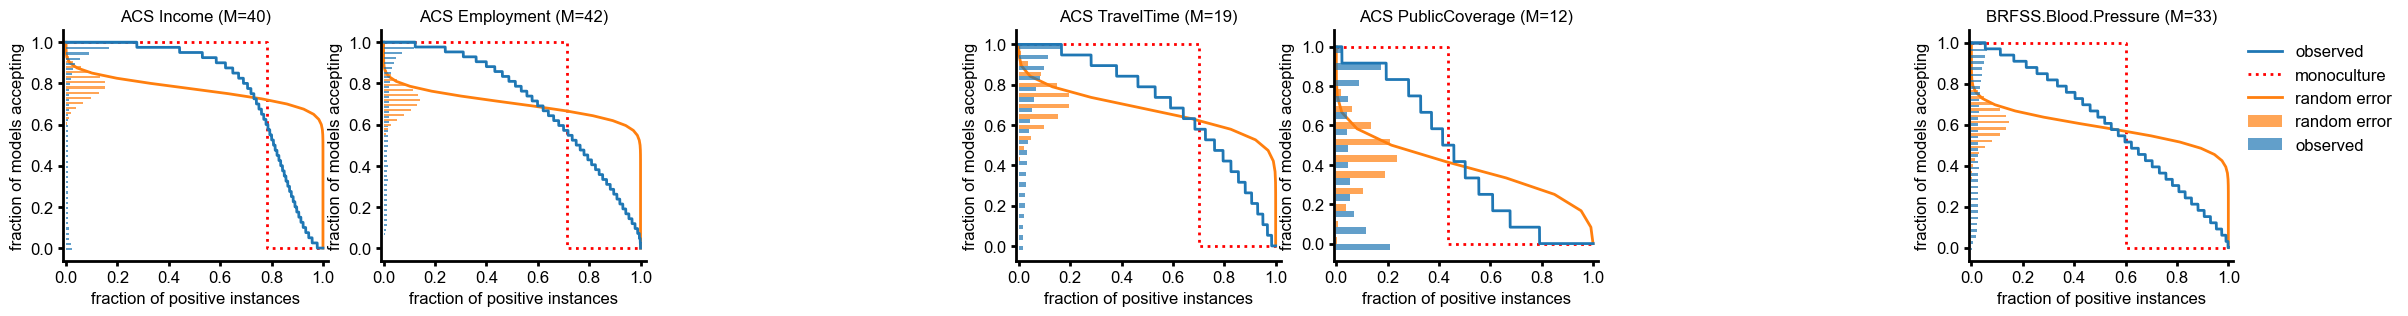

In [11]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']

fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))

sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    M = len(models_sorted)

    if predictions[task].shape[1]>0: 
        axs[i], observed, at_random = plot_recourse_lineplot(
            axs[i],
            predictions=predictions[task],
            baseline_rates=tp_rates[task].to_list(),
            y_true=data[task][1],
            restrict_only_pos_instances=True,
            restrict_only_neg_instances=False,
            count_accepted=True,
            at_least=True,
            plot_pdf=True,
            xlabel="fraction of positive instances",
            ylabel="fraction of models accepting",
            title = f"{task.replace('ACS', 'ACS ').replace('_', '.')} (M={M})"
        )
    else:
        axs[i].set_axis_off()
# legend
handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 1.0))


file_name = "".join(
    [
        f"recourse-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
print(file_name)

plt.show()

## Predicted vs Expected Fraction of Models Accepting an Individual (≈ Calibration Plot)

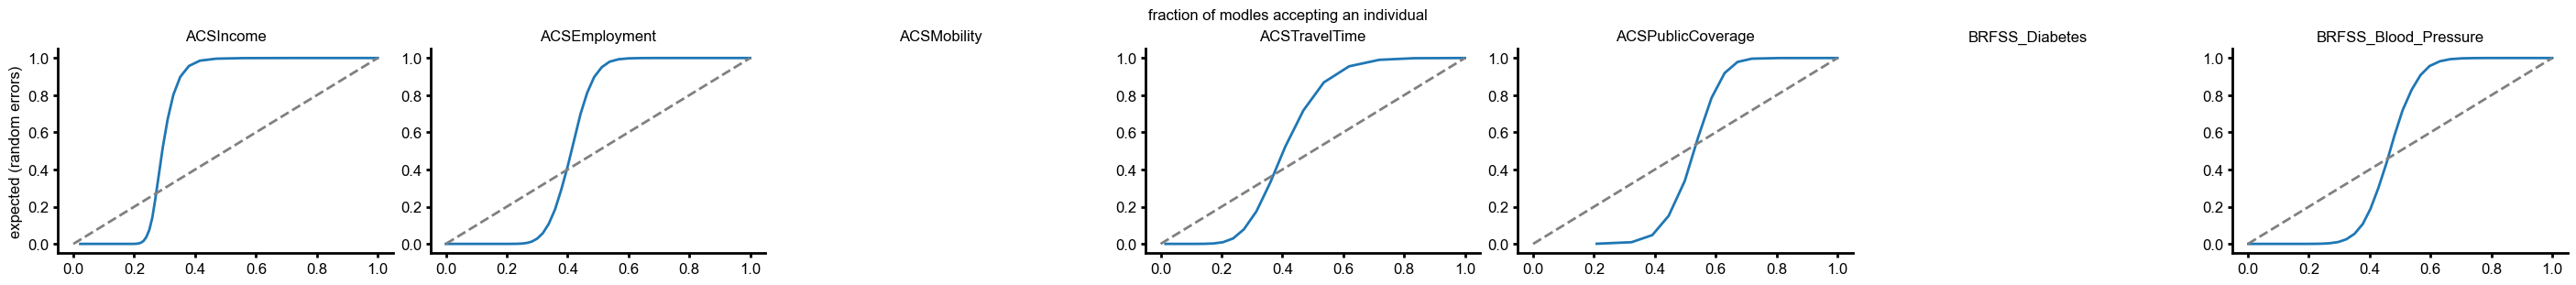

In [12]:
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3), constrained_layout=True)


for i, task in enumerate(tasks_to_plot):
    if predictions[task].shape[1] > 0: 
        num_models, frqs = get_obs_acceptance_aggregated(
            predictions[task],
            restrict_only_pos_instances=True,
            true_labels=data[task][1],
            padding=True,
        )
        frqs = frqs / frqs.sum()

        prob_expected = torch.tensor(
            [
                poisson_binom_agreement(baseline_rate=tp_rates[task].values, k=num_accept)
                for num_accept in range(max(num_models) + 1)
            ]
        )

        axs[i].plot(np.cumsum(frqs.numpy()), np.cumsum(prob_expected.numpy()))
        axs[i].plot([0, 1], [0, 1], color="grey", linestyle="dashed")
    else:
        axs[i].set_axis_off()
    axs[i].set_title(task)


axs[len(tasks_to_plot)//2-1].set_xlabel("observed")
axs[0].set_ylabel("expected (random errors)")
fig.suptitle("fraction of modles accepting an individual")

file_name = "".join(
    [
        f"recourse-calibration-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
        ".png",
    ]
)
plt.savefig(FIGURES_ROOT_DIR / file_name)
plt.show()